# Кейс от команды аналитики и планирования в операционной дирекции

Описание:

В Ламоде есть курьерская доставка. Количество заказов, доступных для оформления клиентов, регулируется через ёмкость слотов доставки. Слоты доставки соответствуют районам (полигонам) адреса курьерской доставки (src_zone_id) и интервалам времени, в который должна быть осуществлена доставка (interval_start_dttm, interval_end_dttm). Каждый слот доставки имеет своё время отсечения (interval_cutoff_dttm), после которого он становится недоступен для выбора клиентом при оформлении заказа. При оформлении клиентом заказа остаточная ёмкость соответствующего слота уменьшается. Также возможно, что ёмкость слота корректируется менеджером вручную, пока этот слот открыт.

Библиотеки для решения кейса

In [1]:
%pip install numpy pandas scipy seaborn matplotlib statsmodels -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import statsmodels as sm
from scipy import stats 
from scipy.optimize import minimize

import seaborn as sns
import matplotlib.pyplot as plt

## Данные о слотах доставки и их заполнении приведены в двух таблицах:

### `intervals.csv` — задекларированная ёмкость слотов

| Поле | Тип | Описание |
|-------|------|----------|
| `slot_id` | `int` | Идентификатор слота (хеш). Ключ связи с `orders`. |
| `interval_start_date` | `date` | Дата доставки слота. Ключ связи с `orders`. |
| `level_2` | `str` | Расположение полигона доставки. Уровень иерархии 2. |
| `level_1` | `str` | Расположение полигона доставки. Уровень иерархии 1. |
| `src_zone_id` | `int` | Идентификатор зоны доставки. |
| `service_level_code` | `str` | Уровень сервиса (`plus15`, `economy`, `exact60`, `same_day` и т.д.). |
| `interval_cutoff_dttm` | `datetime` | Время отсечки приёма заказов в слот (cutoff). |
| `interval_start_dttm` | `datetime` | Начало интервала доставки. |
| `interval_end_dttm` | `datetime` | Конец интервала доставки. |
| `created_at` | `datetime` | Время первого появления интервала в истории (минимальное). |
| `available_capacity_first` | `float` | Первый зафиксированный размер ёмкости слота. `NaN` — если история ёмкости отсутствует. |
| `available_capacity_last` | `float` | Последний зафиксированный размер ёмкости слота. `NaN` — если история отсутствует. |
| `was_expanded` | `int` | `1`, если ёмкость расширялась (`last > first`), иначе `0`. |
| `capacity_delta` | `float` | Изменение ёмкости: `last − first`. |

In [3]:
df_intervals = pd.read_csv('intervals_subset.csv')
df_intervals.head()

,slot_id,interval_start_date,level_2,level_1,src_zone_id,service_level_code,interval_cutoff_dttm,interval_start_dttm,interval_end_dttm,created_at,available_capacity_first,available_capacity_last,was_expanded,capacity_delta
0,20694,2024-09-22,Moscow,LMD Moscow South,1220839,exact60,2024-09-21 23:59:00.000,2024-09-22 18:00:00.000,2024-09-22 19:00:00.000,2024-08-23 02:15:03,2.0,2.0,0,0.0
1,43529,2024-09-07,Moscow,LMD Moscow South,1354357,same_day60,2024-09-07 15:30:00.000,2024-09-07 23:00:00.000,2024-09-07 23:59:00.000,2024-08-08 03:09:12,5.0,5.0,0,0.0
2,44642,2024-10-17,Moscow,LMD Moscow South,1263362,plus15,2024-10-16 23:59:00.000,2024-10-17 19:30:00.000,2024-10-17 19:45:00.000,2024-09-17 02:15:03,2.0,2.0,0,0.0
3,60229,2024-10-22,Moscow,LMD Moscow South,1512698,plus15,2024-10-21 23:59:00.000,2024-10-22 19:00:00.000,2024-10-22 19:15:00.000,2024-09-22 02:15:03,2.0,1.0,0,-1.0
4,88805,2024-09-30,Moscow,LMD Moscow South,1261250,plus15,2024-09-29 23:59:00.000,2024-09-30 08:15:00.000,2024-09-30 08:30:00.000,2024-08-31 02:38:23,1.0,1.0,0,0.0


### `orders.csv` — наполнение слотов заказами

| Поле | Тип | Описание |
|-------|------|----------|
| `slot_id` | `int` | Идентификатор слота, в который попал заказ. Ключ связи с `intervals`. |
| `interval_start_date` | `date` | Дата доставки слота. Ключ связи с `intervals`. |
| `src_zone_id` | `int` | Идентификатор зоны доставки. |
| `service_level_code` | `str` | Уровень сервиса. |
| `interval_start_dttm` | `datetime` | Начало интервала доставки. |
| `interval_end_dttm` | `datetime` | Конец интервала доставки. |
| `order_hour` | `datetime` | Час оформления заказа (округлён вниз до часа, MSK). |
| `consumed_capacity_hourly` | `int` | Количество заказов, оформленных в этот час в данный слот. |
| `consumed_capacity_cum` | `int` | Накопленное потребление слота к этому часу (нарастающим итогом внутри слота). |

In [4]:
df_orders = pd.read_csv('orders_subset.csv')
df_orders.head()

,slot_id,interval_start_date,src_zone_id,service_level_code,interval_start_dttm,interval_end_dttm,order_hour,consumed_capacity_hourly,consumed_capacity_cum
0,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-29 01:00:00.000,1,1
1,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-29 23:00:00.000,1,2
2,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-30 22:00:00.000,1,3
3,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-30 23:00:00.000,1,4
4,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-31 01:00:00.000,2,6


### Связь между `intervals.csv` и `orders.csv`

Один и тот же слот доставки получает одинаковый `slot_id` в обоих датасетах. Связь между таблицами — **many-to-one**: множество почасовых записей заказов в `orders.csv` соответствует одному слоту в `intervals.csv`.

Ключи для объединения таблиц:

- `slot_id`
- `interval_start_date`

Схема связи:

```text
intervals
(slot_id, interval_start_date)
          │
          └─── 1 : N ───► orders
                   (slot_id, interval_start_date)


Гранулярность

- `intervals` — одна строка на слот (slot_id + дата). Уникальный ключ.
- `orders` — одна строка на (слот + час оформления заказа). На один слот может приходиться несколько строк.

## Требуется

- проанализировать данные об истории наполнения слотов доставки,
- сформулировать метрики, характеризующие доступность слотов доставки для клиентов и позволяющие идентифицировать проблемы с ёмкостью и доступностью слотов,
- вывести детальную информацию по слотам, имеющим проблемы, в виде, понятном для операционного менеджера, ответственного за настройку слотов

## Решение

### Анализ данных об истории наполнения слотов доставки

Объеденим наши таблицы в общую

In [5]:
df = df_orders.merge(
    df_intervals,
    on=['slot_id', 'interval_start_date'],
    how='left'
)
df.head()

,slot_id,interval_start_date,src_zone_id_x,service_level_code_x,interval_start_dttm_x,interval_end_dttm_x,order_hour,consumed_capacity_hourly,consumed_capacity_cum,level_2,...,src_zone_id_y,service_level_code_y,interval_cutoff_dttm,interval_start_dttm_y,interval_end_dttm_y,created_at,available_capacity_first,available_capacity_last,was_expanded,capacity_delta
0,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-29 01:00:00.000,1,1,Moscow,...,32.0,economy,2024-08-31 23:59:00.000,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0
1,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-29 23:00:00.000,1,2,Moscow,...,32.0,economy,2024-08-31 23:59:00.000,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0
2,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-30 22:00:00.000,1,3,Moscow,...,32.0,economy,2024-08-31 23:59:00.000,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0
3,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-30 23:00:00.000,1,4,Moscow,...,32.0,economy,2024-08-31 23:59:00.000,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0
4,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-31 01:00:00.000,2,6,Moscow,...,32.0,economy,2024-08-31 23:59:00.000,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0


In [6]:
df = df.drop(columns=[
    'src_zone_id_y',
    'service_level_code_y',
    'interval_start_dttm_y',
    'interval_end_dttm_y'
])

In [7]:
df = df.rename(columns={
    'src_zone_id_x': 'src_zone_id',
    'service_level_code_x': 'service_level_code',
    'interval_start_dttm_x': 'interval_start_dttm',
    'interval_end_dttm_x': 'interval_end_dttm',
    'src_zone_id_y':'src_zone_id',
    'service_level_code_y':'service_level_code',
    'interval_start_dttm_y':'interval_start_dttm',
    'interval_end_dttm_y':'interval_end_dttm'
})
df.head()

,slot_id,interval_start_date,src_zone_id,service_level_code,interval_start_dttm,interval_end_dttm,order_hour,consumed_capacity_hourly,consumed_capacity_cum,level_2,level_1,interval_cutoff_dttm,created_at,available_capacity_first,available_capacity_last,was_expanded,capacity_delta
0,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-29 01:00:00.000,1,1,Moscow,LMD Moscow South,2024-08-31 23:59:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0
1,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-29 23:00:00.000,1,2,Moscow,LMD Moscow South,2024-08-31 23:59:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0
2,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-30 22:00:00.000,1,3,Moscow,LMD Moscow South,2024-08-31 23:59:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0
3,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-30 23:00:00.000,1,4,Moscow,LMD Moscow South,2024-08-31 23:59:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0
4,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-31 01:00:00.000,2,6,Moscow,LMD Moscow South,2024-08-31 23:59:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0


#### Общий обзор данных

Для понимания масштаба наших данных сначала посмотрим, с чем мы работаем.

Для этого посчитаем сколько у нас всего:
- уникальных слотов (`slot_id + interval_start_date`)
- уникальных полигонов (`src_zone_id`)
- слотов по полигонам
- временной диапазон данных (min/max по датам)


Посмотрим сколько у нас уникальных полигонов

In [8]:
df['src_zone_id'].drop_duplicates().shape[0]

168

Посмотрим сколько у нас уникальных слотов с датой начала интервала

In [9]:
df[['slot_id', 'interval_start_date']].drop_duplicates().shape[0]

51989

Посмотрим сколько заказов у нас имеют историю конечной ёмкости

In [10]:
df['available_capacity_last'].isna().sum()/df['available_capacity_last'].count()

np.float64(0.000152389507581378)

Очень маленькое количество поэтому можем их просто убрать

In [11]:
df.dropna(subset=['available_capacity_last'], inplace=True)
df['available_capacity_last'].isna().sum()

np.int64(0)

Сделаем тоже самое для начальной ёмкости

In [12]:
df['available_capacity_first'].isna().sum()/df['available_capacity_first'].count()

np.float64(0.0)

История есть у всех =3

Рассмотрим период данных в датасете

In [13]:
print(f'Дата начала данных: {min(df.interval_start_date)}\nКонечная дата в данных: {max(df.interval_start_date)}')

Дата начала данных: 2024-09-01
Конечная дата в данных: 2024-10-31


#### Анализ истории наполнения слотов

Для удобства анализа выделим из наших данных необходимые нам столбцы и объеденим данные

Начнем с анализа того сколько у нас приходит заказов в слоты по датам

Для этого сначала выделим максимальное значение из столбца `consumed_capacity_cum` по слоту и дню, что нам даст зачение заказов которое пришло в этот слот

И опять сгруппируем по дате, чтобы уже конкретно видеть количество заказов, которые пришли в конкретный день

In [14]:
df_capacity_history = (
  df.groupby(by=['slot_id','interval_start_date'])
  .agg(consumed_capacity_cum=('consumed_capacity_cum', 'max'))
  .reset_index()
)
df_capacity_history.sort_values(by='interval_start_date')
df_capacity_history = df_capacity_history.groupby(by='interval_start_date').agg(consumed_capacity_cum_sum=('consumed_capacity_cum', 'sum')).reset_index()
df_capacity_history

,interval_start_date,consumed_capacity_cum_sum
0,2024-09-01,5599
1,2024-09-02,5640
2,2024-09-03,4998
3,2024-09-04,4615
4,2024-09-05,4618
...,...,...
56,2024-10-27,5510
57,2024-10-28,5909
58,2024-10-29,4488
59,2024-10-30,5264


#### Временной ряд заказов

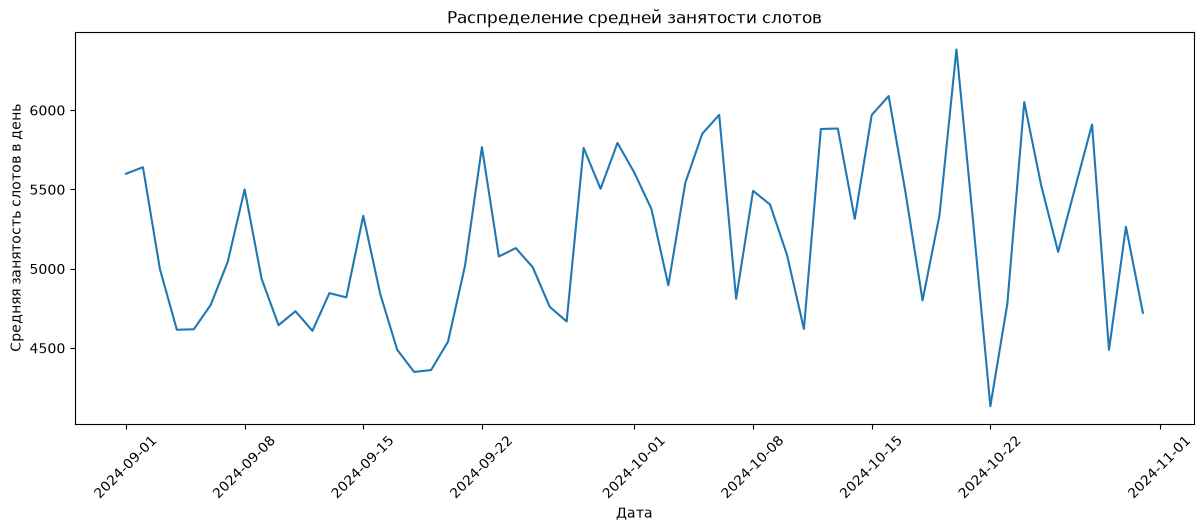

In [15]:
df_capacity_history['interval_start_date'] = pd.to_datetime(
    df_capacity_history['interval_start_date']
)

plt.figure(figsize=(12, 5))
plt.plot(
    df_capacity_history['interval_start_date'],
    df_capacity_history['consumed_capacity_cum_sum']
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.xlabel('Дата')
plt.ylabel('Средняя занятость слотов в день')
plt.title('Распределение средней занятости слотов')
plt.show();

На нем мы видим тренд, который выражен тем, что наши значение плавно возрастают к 11 месяцу посравнению с 9

Также очень видна сезонность, выраженная периодичнымы пиками, но к 11 месяцу из-за увеличения отклонения

Проверим наш ряд на статичность про помощи расширенный тест Дики — Фуллера при помощи библиотеки `statsmodels`

И возьмем из значений, которые нам дает тест, только значение `pvalue` и уровень значимости 5%

In [16]:
from statsmodels.tsa.stattools import adfuller

pvalue = adfuller(df_capacity_history['consumed_capacity_cum_sum'])[1]

pvalue

np.float64(0.6083836764043101)

Теперь построим графики для визуального понимания

Сделаем столбец в котором будет скользящее среднее за 7 периодов

In [17]:
df_capacity_history['ma7'] = (
    df_capacity_history['consumed_capacity_cum_sum']
    .rolling(7)
    .mean()
)

График 

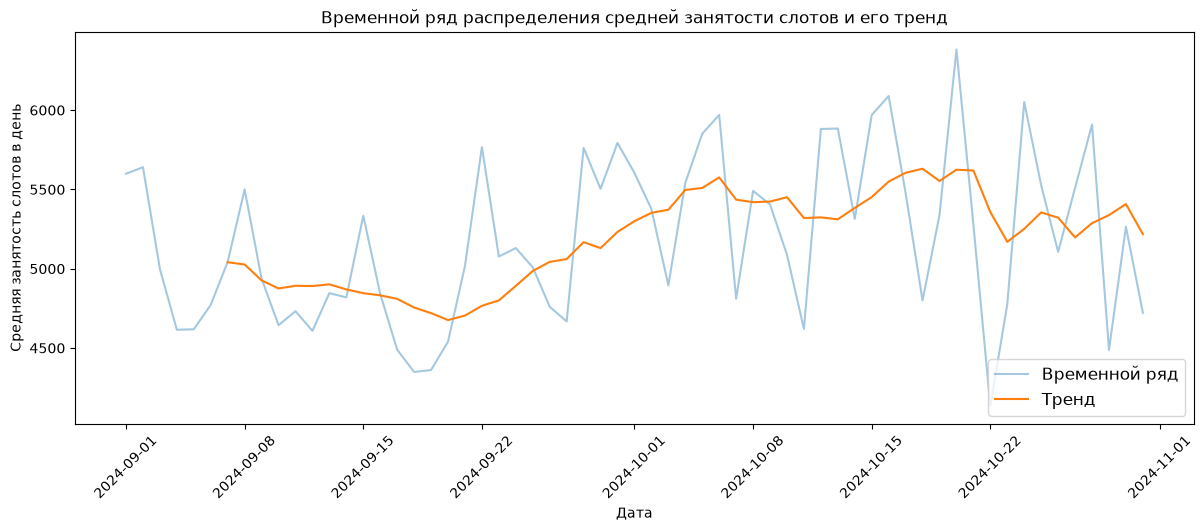

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(df_capacity_history['interval_start_date'],
         df_capacity_history['consumed_capacity_cum_sum'],
         alpha=0.4,
         label='Временной ряд')

plt.plot(df_capacity_history['interval_start_date'],
         df_capacity_history['ma7'],
         label='Тренд')

plt.legend(
    loc='lower right',   
    fontsize=12,            
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.xlabel('Дата')
plt.ylabel('Средняя занятость слотов в день')
plt.title('Временной ряд распределения средней занятости слотов и его тренд')
plt.show();

Помимо тренда можем посмотреть на сезонность и отклонение для этого воспользуемся `seasonal_decompose` из библиотеки `statsmodels`

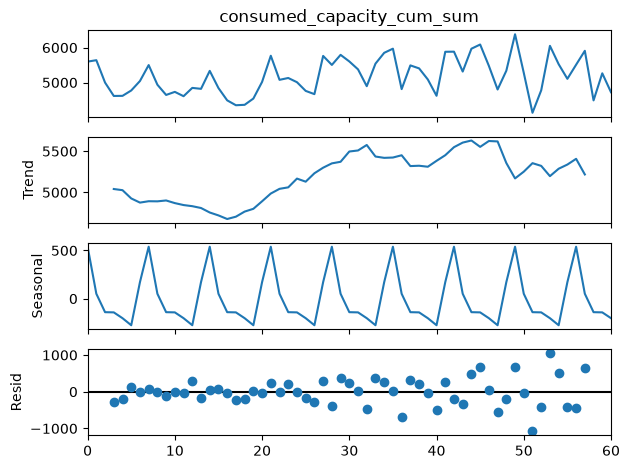

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df_capacity_history['consumed_capacity_cum_sum'],
    period=7
)

result.plot();

Очень ярко выраженная сезонность

Так давайте посмотрим на неё

In [20]:
df_capacity_history['weekday'] = (
    pd.to_datetime(df_capacity_history['interval_start_date'])
    .dt.day_name()
)

df_capacity_history.groupby('weekday')['consumed_capacity_cum_sum'].mean()

weekday
Friday       4913.875000
Monday       5288.888889
Saturday     5352.125000
Sunday       5716.777778
Thursday     4953.333333
Tuesday      4994.000000
Wednesday    5068.555556
Name: consumed_capacity_cum_sum, dtype: float64

Построим боксплот по дням недели

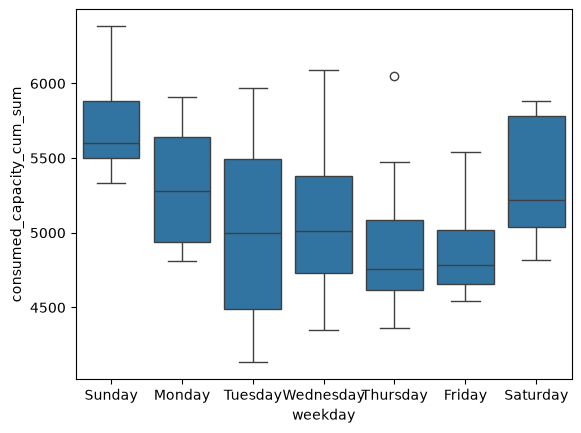

In [21]:
sns.boxplot(
    data=df_capacity_history,
    x='weekday',
    y='consumed_capacity_cum_sum'
);

Видно, что пик заказов в воскресенье спадает к четвергу и с пятницы опять растет

#### Временной ряд расширения емкости

In [22]:
df_capacity_delta_history = (
  df.groupby(by=['slot_id','interval_start_date'])
  .agg(capacity_delta=('capacity_delta', 'max'))
  .reset_index()
)
df_capacity_delta_history.sort_values(by='interval_start_date')
df_capacity_delta_history = df_capacity_delta_history.groupby(by='interval_start_date').agg(capacity_delta_sum=('capacity_delta', 'sum')).reset_index()
df_capacity_delta_history

,interval_start_date,capacity_delta_sum
0,2024-09-01,-6026.0
1,2024-09-02,-3505.0
2,2024-09-03,-2.0
3,2024-09-04,-681.0
4,2024-09-05,-48.0
...,...,...
56,2024-10-27,-5171.0
57,2024-10-28,-3531.0
58,2024-10-29,-1578.0
59,2024-10-30,-2785.0


In [23]:
from statsmodels.tsa.stattools import adfuller

pvalue = adfuller(df_capacity_delta_history['capacity_delta_sum'])[1]

pvalue

np.float64(0.6716583702999153)

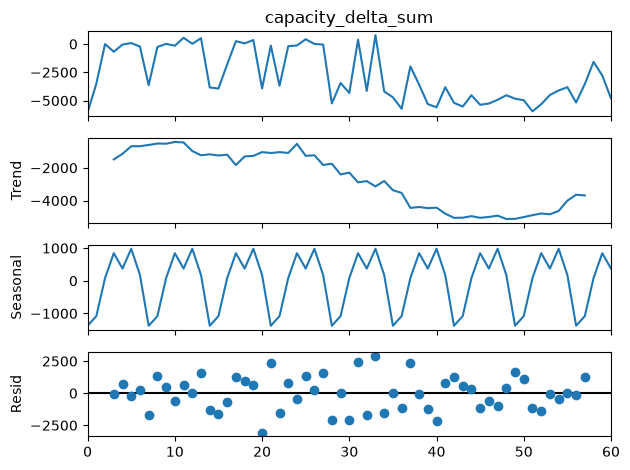

In [24]:
result = seasonal_decompose(
    df_capacity_delta_history['capacity_delta_sum'],
    period=7
)

result.plot();

Тренд выражен падением к концу

Следовательно растет число расширения емкости слота к концу

Что соответствует прошлому временому ряду с тем что у нас росло количество заказов

Сезонность выражена по дням посмотрим поближе

In [25]:
df_capacity_delta_history['weekday'] = (
    pd.to_datetime(df_capacity_delta_history['interval_start_date'])
    .dt.day_name()
)

df_capacity_delta_history.groupby('weekday')['capacity_delta_sum'].mean()

weekday
Friday      -1673.250000
Monday      -3844.222222
Saturday    -2506.250000
Sunday      -4311.777778
Thursday    -2560.000000
Tuesday     -2261.111111
Wednesday   -1930.555556
Name: capacity_delta_sum, dtype: float64

<Axes: xlabel='weekday', ylabel='capacity_delta_sum'>

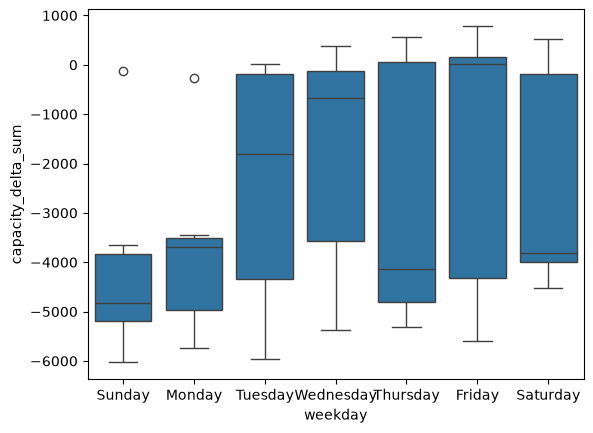

In [26]:
sns.boxplot(
    data=df_capacity_delta_history,
    x='weekday',
    y='capacity_delta_sum'
)

Видно что добавляют емкость слотам пиком в два дня среду и пятницу

Более выраженный пик в пятницу, что говорит о том, что операторы добавляют емкость заранее, поскольку у нас пик заказов приходится на выходные

#### Временной ряд количества расширенных слотов

In [27]:
df_nexpand_history = (
  df.groupby(by=['slot_id','interval_start_date'])
  .agg(was_expanded=('was_expanded', 'sum'))
  .reset_index()
)
df_nexpand_history.sort_values(by='interval_start_date')
df_nexpand_history = df_nexpand_history.groupby(by='interval_start_date').agg(was_expanded_sum=('was_expanded', 'sum')).reset_index()
df_nexpand_history

,interval_start_date,was_expanded_sum
0,2024-09-01,29.0
1,2024-09-02,435.0
2,2024-09-03,291.0
3,2024-09-04,160.0
4,2024-09-05,137.0
...,...,...
56,2024-10-27,60.0
57,2024-10-28,531.0
58,2024-10-29,1228.0
59,2024-10-30,1010.0


In [28]:
from statsmodels.tsa.stattools import adfuller

pvalue = adfuller(df_nexpand_history['was_expanded_sum'])[1]

pvalue

np.float64(1.3696885728656067e-06)

Наше `pvalue` очень маленькое, что говорит о стационарности ряда

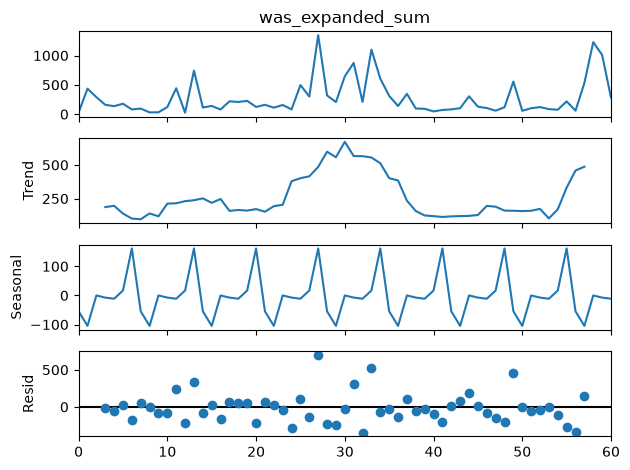

In [29]:
result = seasonal_decompose(
    df_nexpand_history['was_expanded_sum'],
    period=7
)

result.plot();

Видно, что распределение количества расширенных слотов не имеет ярко выраженного тренда, но имеет сезонность, которая говорит о том же, что менеджеры расширяют ёмкость заранее

#### Доля расширенных слотов

In [30]:
nslots = df[['slot_id', 'interval_start_date']].drop_duplicates().shape[0]
nexp_slots = df_nexpand_history.was_expanded_sum.sum()

nexp_slots/nslots

np.float64(0.32459312839059673)

Корреляция сколько заказов в день и сколько добавили емкости

In [31]:
daily_orders = (
    df_orders
    .groupby('interval_start_date')
    ['consumed_capacity_hourly']
    .sum()
    .reset_index()
)


daily_orders.consumed_capacity_hourly.corr(df_capacity_delta_history.capacity_delta_sum)


np.float64(-0.3962103442785438)

In [32]:
daily_orders = (
    df_orders
    .groupby('interval_start_date', as_index=False)
    .agg(daily_orders=('consumed_capacity_hourly', 'sum'))
)

daily_capacity_delta = (
    df_capacity_delta_history
    .groupby('interval_start_date', as_index=False)
    .agg(capacity_delta_sum=('capacity_delta_sum', 'sum'))
)

In [33]:
df_orders2dcapacity = daily_orders.merge(
    daily_capacity_delta,
    on='interval_start_date',
    how='inner'
)

In [34]:
df_orders2dcapacity = df_orders2dcapacity.sort_values('interval_start_date')

df_orders2dcapacity['capacity_delta_lag2'] = df_orders2dcapacity['capacity_delta_sum'].shift(-1)

In [35]:
df_orders2dcapacity[['daily_orders', 'capacity_delta_lag2']].corr()

,daily_orders,capacity_delta_lag2
daily_orders,1.000000,-0.505964
capacity_delta_lag2,-0.505964,1.000000


#### Общий вывод

Временные ряды показали что

- Тренд показывает рост количества заказов с 9 по 11 месяц
- Сезонность количества заказов и увеличение емкости слотов показывает то, что мнеджеры увеличивают емкость заранее. Это же показывает корреляция между количеством заказов и увеличение емкости со сдвигом на два дня назад (-0.5 говорит о средней силе корреляции между факторами, но поскольку у нас дельта между конечной и начальной емкостью, то это прямая корреляция)
- Также сезонность заказов гвоорит о том, что люди больше всего делают заказы на выходных и следовательно сезонность увеличения емкости показывает, что скачек увеличения приходится на период среды, четверга и пятницы 

### Метрики

сформулировать метрики, характеризующие доступность слотов доставки для клиентов и позволяющие идентифицировать проблемы с ёмкостью и доступностью слотов

#### Метрики доступности для клиента

##### Заполненность слота

In [36]:
df.head()

,slot_id,interval_start_date,src_zone_id,service_level_code,interval_start_dttm,interval_end_dttm,order_hour,consumed_capacity_hourly,consumed_capacity_cum,level_2,level_1,interval_cutoff_dttm,created_at,available_capacity_first,available_capacity_last,was_expanded,capacity_delta
0,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-29 01:00:00.000,1,1,Moscow,LMD Moscow South,2024-08-31 23:59:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0
1,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-29 23:00:00.000,1,2,Moscow,LMD Moscow South,2024-08-31 23:59:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0
2,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-30 22:00:00.000,1,3,Moscow,LMD Moscow South,2024-08-31 23:59:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0
3,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-30 23:00:00.000,1,4,Moscow,LMD Moscow South,2024-08-31 23:59:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0
4,637017230,2024-09-01,32,economy,2024-09-01 08:00:00.000,2024-09-01 12:00:00.000,2024-08-31 01:00:00.000,2,6,Moscow,LMD Moscow South,2024-08-31 23:59:00.000,2024-08-02 02:15:03,20.0,11.0,0.0,-9.0


Расчитаем отношение кумулятивной потребляемой емкости как
$$
FullnessPercent = \frac{ConsumedCapacityCum}{AvailableCapacityFirst}
$$

In [37]:
df['fullness_percent'] = df['consumed_capacity_cum']/df['available_capacity_first']

df[['slot_id','interval_start_date','fullness_percent']].head(20)

,slot_id,interval_start_date,fullness_percent
0,637017230,2024-09-01,0.05
1,637017230,2024-09-01,0.10
2,637017230,2024-09-01,0.15
3,637017230,2024-09-01,0.20
4,637017230,2024-09-01,0.30
5,637017230,2024-09-01,0.35
6,637017230,2024-09-01,0.40
7,637017230,2024-09-01,0.50
8,637017230,2024-09-01,0.60
9,3159589450,2024-09-01,0.05


Посмотрим как оно себя ведет

In [38]:
df_fullness_by_day = (
  df.groupby(by=['slot_id', 'interval_start_date'])
  .agg(fullness_percent_end=('fullness_percent', 'max'))
  .reset_index()
)

df_fullness_by_day

,slot_id,interval_start_date,fullness_percent_end
0,189487,2024-10-13,0.333333
1,604881,2024-10-10,0.950000
2,661778,2024-09-03,0.400000
3,742364,2024-10-15,0.896552
4,1010533,2024-10-15,0.454545
...,...,...,...
51977,4294538455,2024-10-20,0.250000
51978,4294662154,2024-10-02,1.333333
51979,4294838198,2024-09-13,1.000000
51980,4294852545,2024-09-05,0.250000


Относительно слота (средняя заполненность слота за все время)

In [39]:
df_mean_fullness_slots = df_fullness_by_day.groupby(by='slot_id').agg(mean_fullness=('fullness_percent_end','mean')).reset_index()
df_mean_fullness_slots

,slot_id,mean_fullness
0,189487,0.333333
1,604881,0.950000
2,661778,0.400000
3,742364,0.896552
4,1010533,0.454545
...,...,...
51977,4294538455,0.250000
51978,4294662154,1.333333
51979,4294838198,1.000000
51980,4294852545,0.250000


<Axes: >

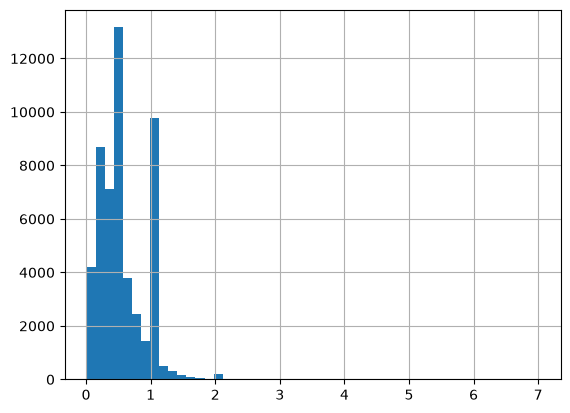

In [40]:
df_mean_fullness_slots.mean_fullness.hist(bins=50)

In [41]:
df_mean_fullness_slots[df_mean_fullness_slots['mean_fullness'] > 2].count()

slot_id          51
mean_fullness    51
dtype: int64

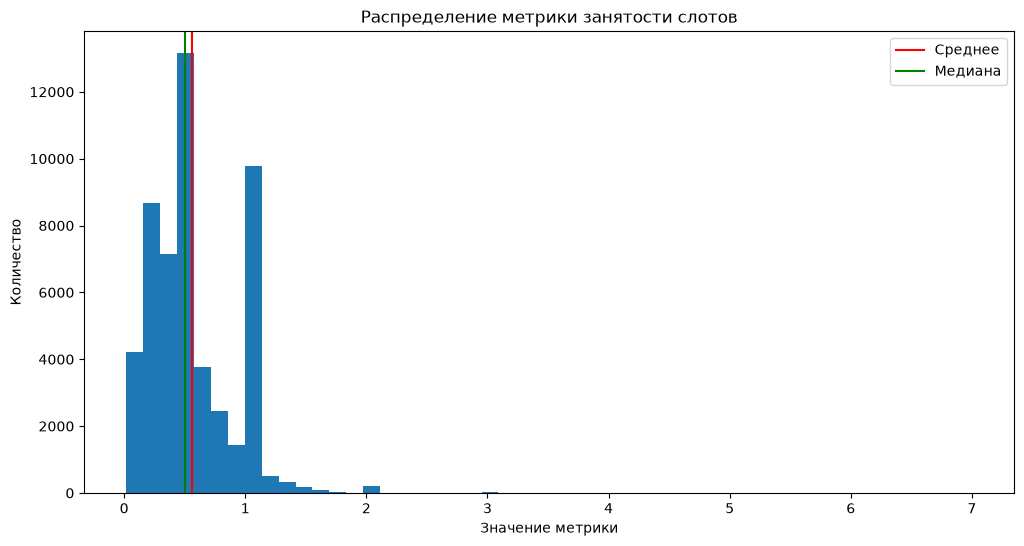

In [42]:
plt.figure(figsize=(12,6))

plt.hist(df_mean_fullness_slots.mean_fullness, bins=50)
plt.title('Распределение метрики занятости слотов')
plt.xlabel('Значение метрики')
plt.ylabel('Количество')
plt.axvline(df_mean_fullness_slots.mean_fullness.mean(), color='red', label='Среднее')
plt.axvline(df_mean_fullness_slots.mean_fullness.median(), color='green', label='Медиана')
plt.legend()
plt.show();

Относительно даты (средняя заполненность слотов в каждый день)

In [43]:
df_mean_fullness_date = df_fullness_by_day.groupby(by='interval_start_date').agg(mean_fullness=('fullness_percent_end','mean')).reset_index()
df_mean_fullness_date

,interval_start_date,mean_fullness
0,2024-09-01,0.536595
1,2024-09-02,0.630257
2,2024-09-03,0.564837
3,2024-09-04,0.557419
4,2024-09-05,0.559997
...,...,...
56,2024-10-27,0.544367
57,2024-10-28,0.593863
58,2024-10-29,0.510564
59,2024-10-30,0.530067


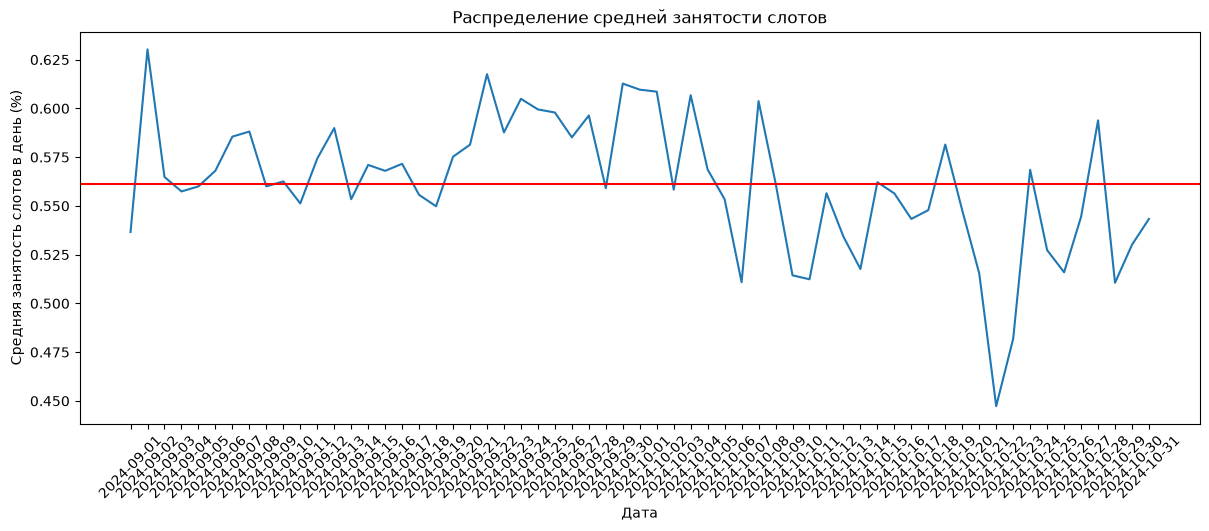

In [44]:
plt.figure(figsize=(12, 5))
plt.plot(
    df_mean_fullness_date['interval_start_date'],
    df_mean_fullness_date['mean_fullness']
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.xlabel('Дата')
plt.ylabel('Средняя занятость слотов в день (%)')
plt.title('Распределение средней занятости слотов')
plt.axhline(df_mean_fullness_date['mean_fullness'].mean(), color='red', label='Среднее')
plt.show();

##### Скорость заполнения слота

Будем смотреть с какой скоростью у нас идет заполнение слота по часам

$$
SlotVelocity = \frac{TotalOrders}{ActiveHours}
$$

In [45]:
slot_velocity = (
    df.groupby(['slot_id', 'interval_start_date'])
      .agg(
          total_orders=('consumed_capacity_hourly', 'sum'),
          active_hours=('order_hour', 'nunique')
      )
      .reset_index()
)

slot_velocity['avg_hourly_velocity'] = (
    slot_velocity['total_orders']
    / slot_velocity['active_hours']
)
slot_velocity.avg_hourly_velocity.mean()

np.float64(1.0959226047700679)

<Axes: >

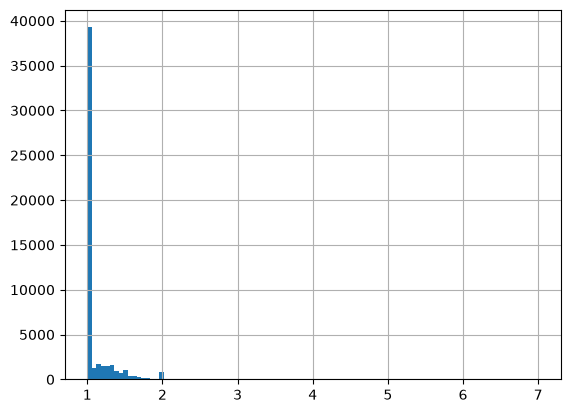

In [46]:
slot_velocity.avg_hourly_velocity.hist(bins=100)

У нас очень много слотов где у нас 1 заказ в час

Также длинный хвост показывает на выбросы

In [47]:
slot_velocity.avg_hourly_velocity.max()

np.float64(7.0)

Получаем что один слот у нас пашет 7 заказов в час

In [48]:
slot_velocity[slot_velocity['avg_hourly_velocity'] > 2].count()

slot_id                261
interval_start_date    261
total_orders           261
active_hours           261
avg_hourly_velocity    261
dtype: int64

И в целом 260 слотов которые работают больше чем 2 заказа в час

На основе этого можно распределить другие заказы на менее нагруженные слоты

##### Доля слотов, ставших недоступными до cutoff

Сначала определяем какие у нас слоты доступны по условию того, что у нас заказ приходится на время до `cutoff` и слот не заполнен

и далее расчитываем сколько слотов которые стали недоступными до `cutoff`

$$
NoSlotRate = \frac{NoSlotHours}{TotalHours}
$$

In [49]:
df['is_available'] = (
    (df['consumed_capacity_cum'] < df['available_capacity_first']) &
    (df['order_hour'] <= df['interval_cutoff_dttm'])
)

In [50]:
hourly_slots = (
    df.groupby(['src_zone_id', 'order_hour'])
      .agg(
          available_slots=('is_available', 'sum')
      )
      .reset_index()
)

In [51]:
hourly_slots['no_slots'] = (
    hourly_slots['available_slots'] == 0
)

In [52]:
no_slot_rate = (
    hourly_slots.groupby('src_zone_id')
    .agg(
        total_hours=('no_slots', 'size'),
        no_slot_hours=('no_slots', 'sum')
    )
)

no_slot_rate['no_slot_rate'] = (
    no_slot_rate['no_slot_hours']
    / no_slot_rate['total_hours']
)

no_slot_rate.no_slot_rate

src_zone_id
32         0.005529
35         0.027273
36         0.062914
37         0.048359
38         0.005316
             ...   
1583511    0.229814
1583515    0.278302
1583517    0.397059
1583518    0.395833
1605054    0.000000
Name: no_slot_rate, Length: 161, dtype: float64

In [53]:
no_slot_rate[no_slot_rate.no_slot_rate == no_slot_rate.no_slot_rate.max()]

,total_hours,no_slot_hours,no_slot_rate
src_zone_id,,,
1548017,6,5,0.833333


In [54]:
no_slot_rate_data = np.array(no_slot_rate['no_slot_rate'])
alpha=0.05

left = np.quantile(no_slot_rate_data, alpha/2)
right = np.quantile(no_slot_rate_data, 1-alpha/2)

In [55]:
left, right

(np.float64(0.0), np.float64(0.5645161290322581))

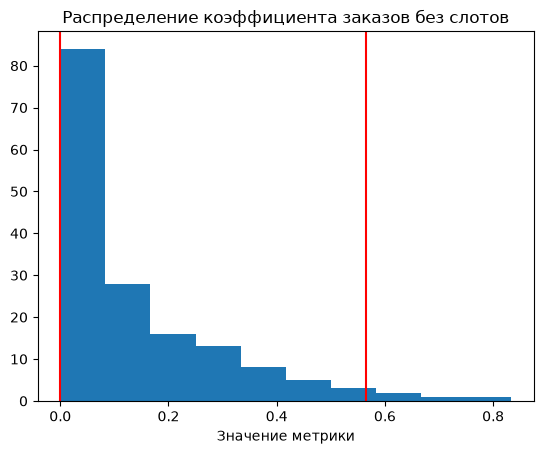

In [56]:
plt.Figure(figsize=(12,6))

plt.hist(no_slot_rate.no_slot_rate)
plt.title('Распределение коэффициента заказов без слотов')
plt.xlabel('Значение метрики')
plt.axvline(left, color='red')
plt.axvline(right, color='red')

plt.show();

Как мы видим, что доля заказов до отреза интервала в основном 0 при этом 95% результатов лежит в интервале (0, 0.56)

#### Метрики для определения проблем с емкостью

##### Доля слотов, которые пришлось расширять.

$$
ExpansionRate = \frac{ExpandedSlots}{AllSlots}
$$

In [57]:
df_intervals['was_expanded'].mean()

np.float64(0.01600862965192174)

Также помимо доли слотов посмотрим средний объем расширения слотов

In [58]:
df_intervals[df_intervals['was_expanded']==1]['capacity_delta'].mean()

np.float64(3.179931640625)

##### Коэффициент использования ёмкости

$$
CapacityUtilization = \frac{Consumed_final}{AvalibleCapacity_final}
$$

Интерпретация:

- CU < 1 избыток 
- CU ~ 1 баланс
- CU > 1 нехватка ёмкости и зависимость от расширений

Можно анализировать среднее значение и распределение по зонам и сервисам

In [59]:
slot_usage = (
    df_orders.groupby(['slot_id', 'interval_start_date'])
    .agg(
        consumed_final=('consumed_capacity_cum', 'max')
    )
    .reset_index()
)

In [60]:
slot_usage = slot_usage.merge(
    df_intervals[['slot_id', 'interval_start_date', 'available_capacity_first']],
    on=['slot_id', 'interval_start_date'],
    how='left'
)

In [61]:
slot_usage['capacity_utilization'] = (
    slot_usage['consumed_final'] /
    slot_usage['available_capacity_first']
)

In [62]:
util_mean = slot_usage['capacity_utilization'].mean()
util_median = slot_usage['capacity_utilization'].median()
util_p95 = slot_usage['capacity_utilization'].quantile(0.95)

print(f'Среднее использование ёмкости: {util_mean} \
      \nМедиана использования ёмкости: {util_median} \
      \nКвантиль 95%: {util_p95}')

Среднее использование ёмкости: 0.5588804449481909       
Медиана использования ёмкости: 0.5       
Квантиль 95%: 1.0


У нас очень много недозагрузки слотов

##### Неравномерность загрузки

$$
CV = \frac{\sigma(CapacityUtilization)}{\mu(CapacityUtilization)}
$$

Высокое значение означает, что часть слотов регулярно переполнена, а часть остаётся полупустой

In [63]:
cv = slot_usage['capacity_utilization'].std() / slot_usage['capacity_utilization'].mean()
cv

np.float64(0.6159351444977339)

У нас высокий дисбаланс наполнености слотов

### Операционный менеджер

#### Информация для вывода

Для менеджера, поскольку ему необходимо настраивать слоты, нужно вывести следующую информацию

`result`

| Поле                     | Зачем менеджеру                             |
| ------------------------ | ------------------------------------------- |
| slot_id                  | идентификатор слота                         |
| src_zone_id              | в какой зоне проблема                       |
| service_level_code       | какой сервис                                |
| interval_start_dttm      | когда доставка                              |
| interval_cutoff_dttm     | до какого момента слот должен быть доступен |
| available_capacity_first | первоначальная ёмкость                      |
| available_capacity_last  | итоговая ёмкость                            |
| consumed_final           | сколько заказов принято                     |
| capacity_utilization     | использование ёмкости                       |
| was_expanded             | было ли расширение                          |
| capacity_delta           | насколько расширили                         |
| time_to_unavailable      | когда слот закончился                       |
| lead_to_cutoff           | за сколько до cutoff закончился             |
| avg_hourly_velocity      | средняя скорость заполнения                 |
| problem_type             | тип проблемы                                |


Также добавим классификацию проблемы, чтобы было видно, что происходит в слоте

`problem_type`
- Переполнение (fullness > 1)
- Ранее закрытие (слот закончился до cutoff)
- Частые расширения (у слота многоповторное расширение)
- Слишком быстрое заполнение (velocity > P95)
- Недозагрузка (fullness < 0.5)

Начнем с того, что сначала определим наш скелет конечной таблицы по нашем исходной. Выделим из начальной таблицы все что нам необходимо

In [64]:
result = (
    df.groupby(['slot_id', 'interval_start_date'])
      .agg(
          src_zone_id=('src_zone_id', 'first'),
          service_level_code=('service_level_code', 'first'),

          interval_start_dttm=('interval_start_dttm', 'first'),
          interval_end_dttm=('interval_end_dttm', 'first'),
          interval_cutoff_dttm=('interval_cutoff_dttm', 'first'),

          created_at=('created_at', 'first'),

          available_capacity_first=('available_capacity_first', 'first'),
          available_capacity_last=('available_capacity_last', 'first'),

          was_expanded=('was_expanded', 'first'),
          capacity_delta=('capacity_delta', 'first'),

          consumed_final=('consumed_capacity_cum', 'max'),

          avg_hourly_velocity=('consumed_capacity_hourly', 'mean'),
          max_hourly_velocity=('consumed_capacity_hourly', 'max')
      )
      .reset_index()
)

Посчитаем метрику Capacity Utilization

In [66]:
result['capacity_utilization'] = (
    result['consumed_final']
    / result['available_capacity_first']
)

Определим слоты и в какой момент была исчермана изначальная ёмкость

In [67]:
sold_out = (
    df[df['consumed_capacity_cum'] >= df['available_capacity_first']]
      .sort_values('order_hour')
      .groupby(['slot_id','interval_start_date'])
      .first()[['order_hour']]
      .rename(columns={'order_hour':'sold_out_time'})
      .reset_index()
)

result = result.merge(
    sold_out,
    on=['slot_id','interval_start_date'],
    how='left'
)

Определим за сколько до `cutoff` слот закончился

Если слот не закончился об этом будет говорить значение `Nan`

In [69]:
result['lead_to_cutoff_hours'] = (
    (
        pd.to_datetime(result['interval_cutoff_dttm'])
        - pd.to_datetime(result['sold_out_time'])
    )
    .dt.total_seconds() / 3600
)

Определим 95% персентиль для "слишком высокой" скорости заполнения слота

In [70]:
velocity_thr = result['avg_hourly_velocity'].quantile(0.95)

Сделаем функцию которая будет отвечать за распределение проблем по нашим слотам

In [71]:
def classify_problem(row):

    problems = []

    if row['capacity_utilization'] > 1:
        problems.append('Переполнение')

    if row['was_expanded'] == 1:
        problems.append('Расширение ёмкости')

    if (
        pd.notna(row['lead_to_cutoff_hours'])
        and row['lead_to_cutoff_hours'] > 0
    ):
        problems.append('Закончился до cutoff')

    if row['avg_hourly_velocity'] > velocity_thr:
        problems.append('Высокая скорость заполнения')

    if row['capacity_utilization'] < 0.5:
        problems.append('Недозагрузка')

    if len(problems) == 0:
        return 'Без проблем'

    return '; '.join(problems)

In [73]:
result['problem_type'] = result.apply(classify_problem, axis=1)

#### Итоговая таблица

In [74]:
result[result['problem_type'] != 'Без проблем']

,slot_id,interval_start_date,src_zone_id,service_level_code,interval_start_dttm,interval_end_dttm,interval_cutoff_dttm,created_at,available_capacity_first,available_capacity_last,was_expanded,capacity_delta,consumed_final,avg_hourly_velocity,max_hourly_velocity,capacity_utilization,sold_out_time,lead_to_cutoff_hours,problem_type
0,189487,2024-10-13,1513143,exact60,2024-10-13 19:00:00.000,2024-10-13 20:00:00.000,2024-10-12 23:59:00.000,2024-09-13 02:39:19,3.0,1.0,0.0,-2.0,1,1.000000,1,0.333333,NaN,NaN,Недозагрузка
1,604881,2024-10-10,35,plus,2024-10-10 09:00:00.000,2024-10-10 13:00:00.000,2024-10-09 23:59:00.000,2024-09-10 02:37:38,40.0,35.0,0.0,-5.0,38,1.520000,3,0.950000,NaN,NaN,Высокая скорость заполнения
2,661778,2024-09-03,1261252,economy,2024-09-03 12:00:00.000,2024-09-03 16:00:00.000,2024-09-02 23:59:00.000,2024-08-04 02:15:03,20.0,20.0,0.0,0.0,8,1.333333,3,0.400000,NaN,NaN,Недозагрузка
4,1010533,2024-10-15,1513142,economy,2024-10-15 16:00:00.000,2024-10-15 20:00:00.000,2024-10-14 23:59:00.000,2024-09-15 02:15:03,11.0,5.0,0.0,-6.0,5,1.000000,1,0.454545,NaN,NaN,Недозагрузка
6,1197767,2024-10-19,32,exact60,2024-10-19 22:00:00.000,2024-10-19 23:00:00.000,2024-10-18 23:59:00.000,2024-09-19 02:15:03,1.0,1.0,0.0,0.0,1,1.000000,1,1.000000,2024-10-17 22:00:00.000,25.983333,Закончился до cutoff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51975,4294531875,2024-10-27,1199242,exact60,2024-10-27 11:00:00.000,2024-10-27 12:00:00.000,2024-10-26 23:59:00.000,2024-09-27 02:24:07,1.0,1.0,0.0,0.0,1,1.000000,1,1.000000,2024-10-26 23:00:00.000,0.983333,Закончился до cutoff
51977,4294538455,2024-10-20,1101682,exact60,2024-10-20 20:00:00.000,2024-10-20 21:00:00.000,2024-10-19 23:59:00.000,2024-09-20 02:15:03,4.0,1.0,0.0,-3.0,1,1.000000,1,0.250000,NaN,NaN,Недозагрузка
51978,4294662154,2024-10-02,1253463,exact60,2024-10-02 13:00:00.000,2024-10-02 14:00:00.000,2024-10-01 23:59:00.000,2024-09-02 02:38:44,3.0,3.0,0.0,0.0,4,1.000000,1,1.333333,2024-10-01 15:00:00.000,8.983333,Переполнение; Закончился до cutoff
51979,4294838198,2024-09-13,1467568,economy,2024-09-13 08:00:00.000,2024-09-13 12:00:00.000,2024-09-12 23:59:00.000,2024-08-14 02:38:56,10.0,10.0,0.0,0.0,10,1.000000,1,1.000000,2024-09-12 22:00:00.000,1.983333,Закончился до cutoff
